<a href="https://colab.research.google.com/github/KrishDataLab/ML_Narchukoora_babu/blob/main/Data_processing_Methods_on_Regression_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#About Dataset
###Description
This dataset provides essential demographic data with three columns: Gender, Height, and Weight. The Gender column categorizes each entry as male or female, while Height (in centimeters) and Weight (in kilograms) offer key physical measurements. Ideal for regression analysis, this dataset allows users to explore relationships between gender, height, and weight, making it suitable for projects in health, fitness, and demographic studies.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Loading Dataset

In [4]:
import kagglehub
path = kagglehub.dataset_download("muhammaddawood42/regression-dataset")

100%|██████████| 167k/167k [00:00<00:00, 45.6MB/s]

Extracting files...


In [7]:
import os

csv_file_name = "weight-height.csv"

csv_file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(csv_file_path)







#Data Processing

Removing Duplicates

Handling Missing values

Handling Outliers

Data type Conversion

Categorical Encoding

Feature Scaling

Feature Selection

Data Leakage


In [12]:
df.head()


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [13]:
df.shape

(10000, 3)

In [15]:
df.drop_duplicates()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


##Dealing with missing values
    

1.   Mean

2.   Median

2.   Mode







In [16]:
df.isnull().sum() # null values are Zero

,0
Gender,0
Height,0
Weight,0


In [18]:
df.isnull() # A boolean mask

,Gender,Height,Weight
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
9995,False,False,False
9996,False,False,False
9997,False,False,False
9998,False,False,False


In [17]:
df.isnull().sum().sum() # checking Overall

np.int64(0)

In [20]:
df[df["Height"].isnull()] #Checking rows where is missing values
df[df["Gender"].isnull()]
df[df["Weight"].isnull()]



,Gender,Height,Weight


In [21]:
(df.isnull().sum() / len(df)) * 100 #percentage of missing values

,0
Gender,0.0
Height,0.0
Weight,0.0


### Handling Outliers

##IQR Method (Trimming / Dropping Outliers)

In [22]:
# 1. Calculate Q1, Q3, and IQR for Height
Q1 = df['Height'].quantile(0.25)
Q3 = df['Height'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter out outliers
df_filtered = df[(df['Height'] >= lower_bound) & (df['Height'] <= upper_bound)]

print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

Original shape: (10000, 3)
Filtered shape: (9992, 3)


##Winsorization / Capping (Replacing Extreme Values)

In [23]:
# Cap values above upper bound and below lower bound
df['Height_Capped'] = df['Height'].clip(lower=lower_bound, upper=upper_bound)

##Z-Score Method (Parametric)

In [24]:
from scipy import stats

# Calculate Z-scores for Height
df['Height_zscore'] = stats.zscore(df['Height'])

# Keep only rows within 3 standard deviations
df_no_outliers = df[df['Height_zscore'].abs() <= 3]

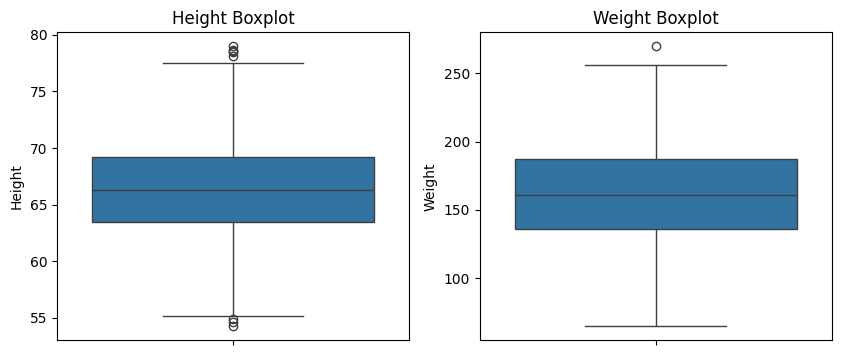

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing outliers in Height and Weight
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Height'])
plt.title('Height Boxplot')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Weight'])
plt.title('Weight Boxplot')

plt.show()

##DataType Conversion

In [26]:
df.dtypes

,0
Gender,object
Height,float64
Weight,float64
Height_Capped,float64
Height_zscore,float64


In [27]:
# Convert floats to integers (if whole numbers are preferred)
df['Height'] = df['Height'].astype(int)

# Convert Gender to category (saves memory and speeds up computations for categorical variables)
df['Gender'] = df['Gender'].astype('category')

In [28]:
# Force conversion to float, turning invalid text entries into NaN
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

In [29]:
df = df.astype({
      'Gender': 'category',
      'Height': 'float32',
      'Weight': 'float32'
              })


In [30]:
df.dtypes

,0
Gender,category
Height,float32
Weight,float32
Height_Capped,float64
Height_zscore,float64


## Categorical Encoding

In [31]:
#Option A: One-Hot Encoding
# Creates dummy columns: Gender_Male, Gender_Female (dropping one avoids collinearity)
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df.head()


,Height,Weight,Height_Capped,Height_zscore,Gender_Male
0,73.0,241.893570,73.847017,1.944061,True
1,68.0,162.310471,68.781904,0.627537,True
2,74.0,212.740860,74.110105,2.012443,True
3,71.0,220.042465,71.730978,1.394060,True
4,69.0,206.349808,69.881796,0.913421,True


In [33]:
#Option B: Label / Binary Mapping
# The 'Gender' column was already converted to 'Gender_Male' by pd.get_dummies.
# To convert 'Gender_Male' (boolean) to integers (1 for Male, 0 for Female):
df['Gender_Male'] = df['Gender_Male'].astype(int)

##Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df[['Gender_Male', 'Height']] # or your feature set
y = df['Weight']                  # target variable

# Option A: StandardScaler (Mean = 0, Std = 1) - Best for normally distributed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Option B: MinMaxScaler (Scales values between 0 and 1)
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(X)

##Data Leakage (Prevention)

In [35]:
from sklearn.model_selection import train_test_split

# 1. Split into train and test FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit the scaler ONLY on training data, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use transform(), NEVER fit_transform() on test!

##Feature Selection

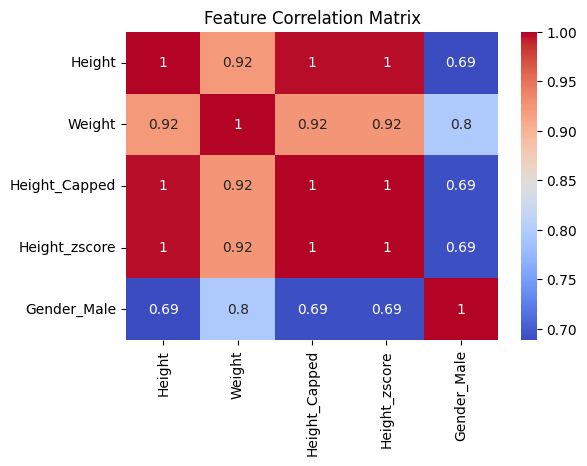

In [36]:
#Option A: Correlation Analysis (Filter Method)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [37]:
#Option B: Automated Selection with Scikit-Learn (SelectKBest)
from sklearn.feature_selection import SelectKBest, f_regression

# Select the top K features based on correlation score with target (y)
selector = SelectKBest(score_func=f_regression, k='all')
X_selected = selector.fit_transform(X_train_scaled, y_train)

# View feature scores
for col, score in zip(X.columns, selector.scores_):
    print(f"Feature: {col} | Score: {score:.2f}")

Feature: Gender_Male | Score: 13704.60
Feature: Height | Score: 45082.69


##Training , Testing, Split

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
X = df[['Gender_Male', 'Height']]
y = df['Weight']

# 2. Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
    )

# 3. Scale Features (fit ONLY on training set to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Loading Model

In [44]:
model = LinearRegression()

In [45]:
#Training face
model.fit(X_train_scaled, y_train)


LinearRegression()

In [46]:
y_pred = model.predict(X_test_scaled)


###Evaluate Model Performance

In [47]:
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 104.95
R² Score: 0.8998


###Compare Actual vs. Predicted Values

In [49]:
# Create a summary table of actual vs predicted weight
results = pd.DataFrame({
    'Actual Weight': y_test.values,
        'Predicted Weight': y_pred
        })

results.head()

,Actual Weight,Predicted Weight
0,173.115814,164.142154
1,195.162048,183.880951
2,170.217453,172.074367
3,215.049667,201.590826
4,182.721451,177.977659
